<a href="https://colab.research.google.com/github/sonia-rafique/Data-Science-Artifacts/blob/main/Task%203%20/%20Power_Energy_Consumption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy matplotlib seaborn statsmodels prophet xgboost scikit-learn

Initializing Production Data Ingestion Pipeline...
Resampling series to Hourly grain...
Executing Deep Exploratory Data Analysis and Diagnostic Rendering...


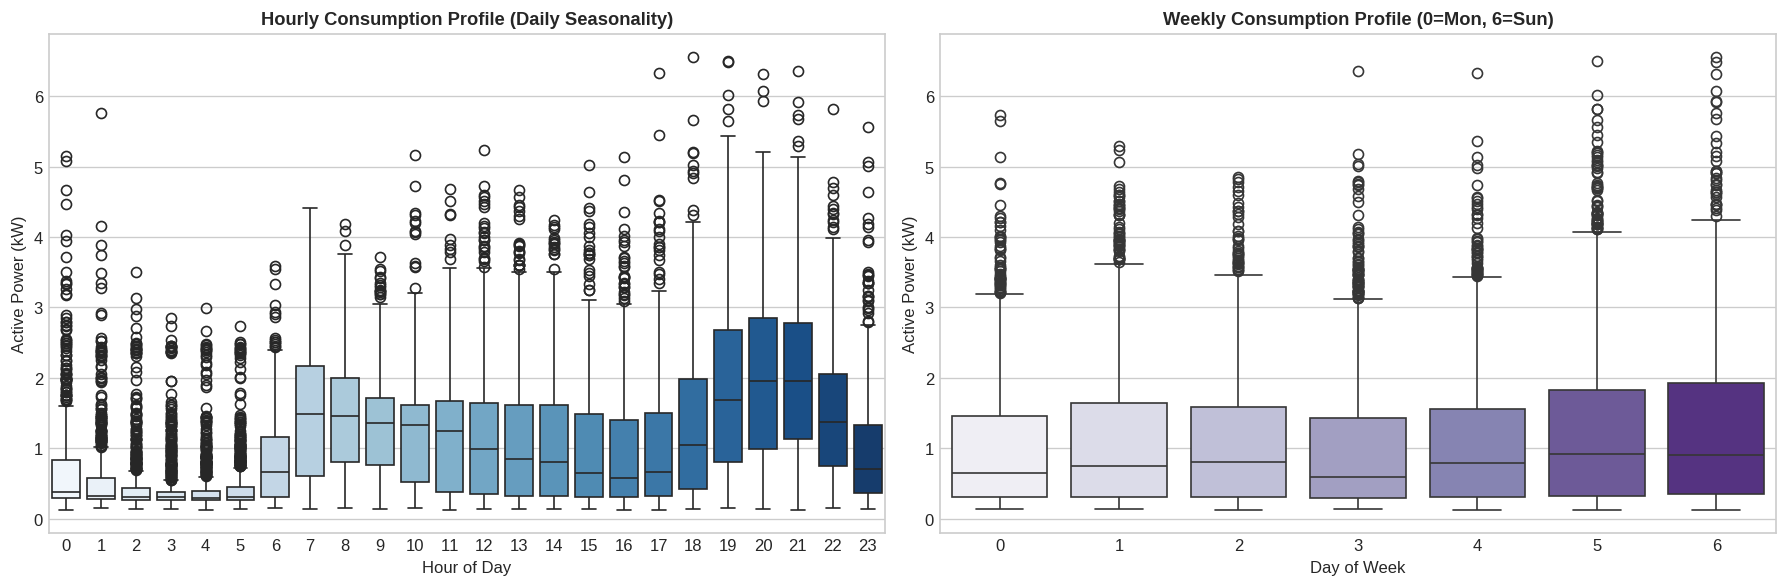

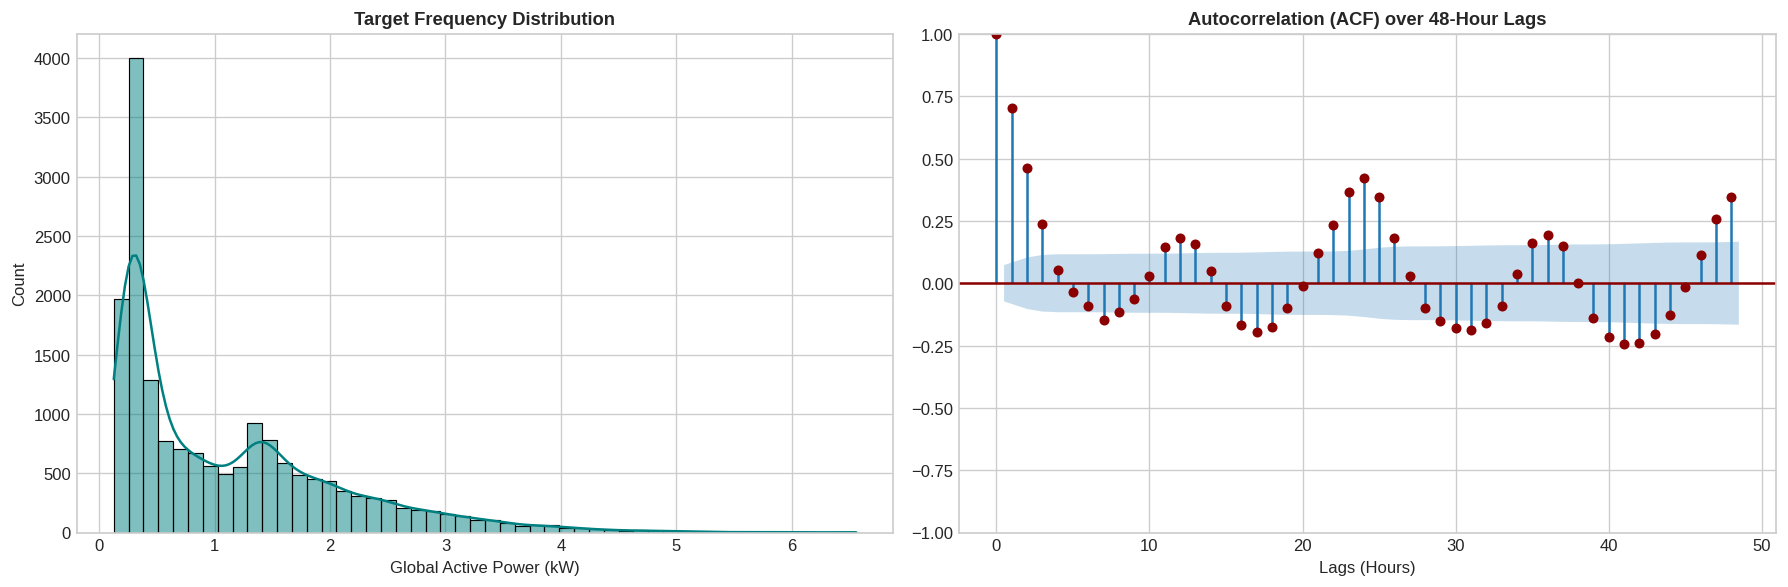


Training Model 1: Classical ARIMA Sequence Model...
Training Model 2: Holt-Winters Exponential Smoothing...
Training Model 3: Gradient Boosting Ensemble...

Evaluating Model Standings Against Test Ground Truth:
  ARIMA Results -> MAE: 0.7499 kW | RMSE: 0.9218 kW
  Exp Smoothing Results -> MAE: 0.7053 kW | RMSE: 0.9046 kW
  Gradient Boosting Results -> MAE: 0.4934 kW | RMSE: 0.6549 kW

Generating Diagnostic Curves and Performance Dashboards...


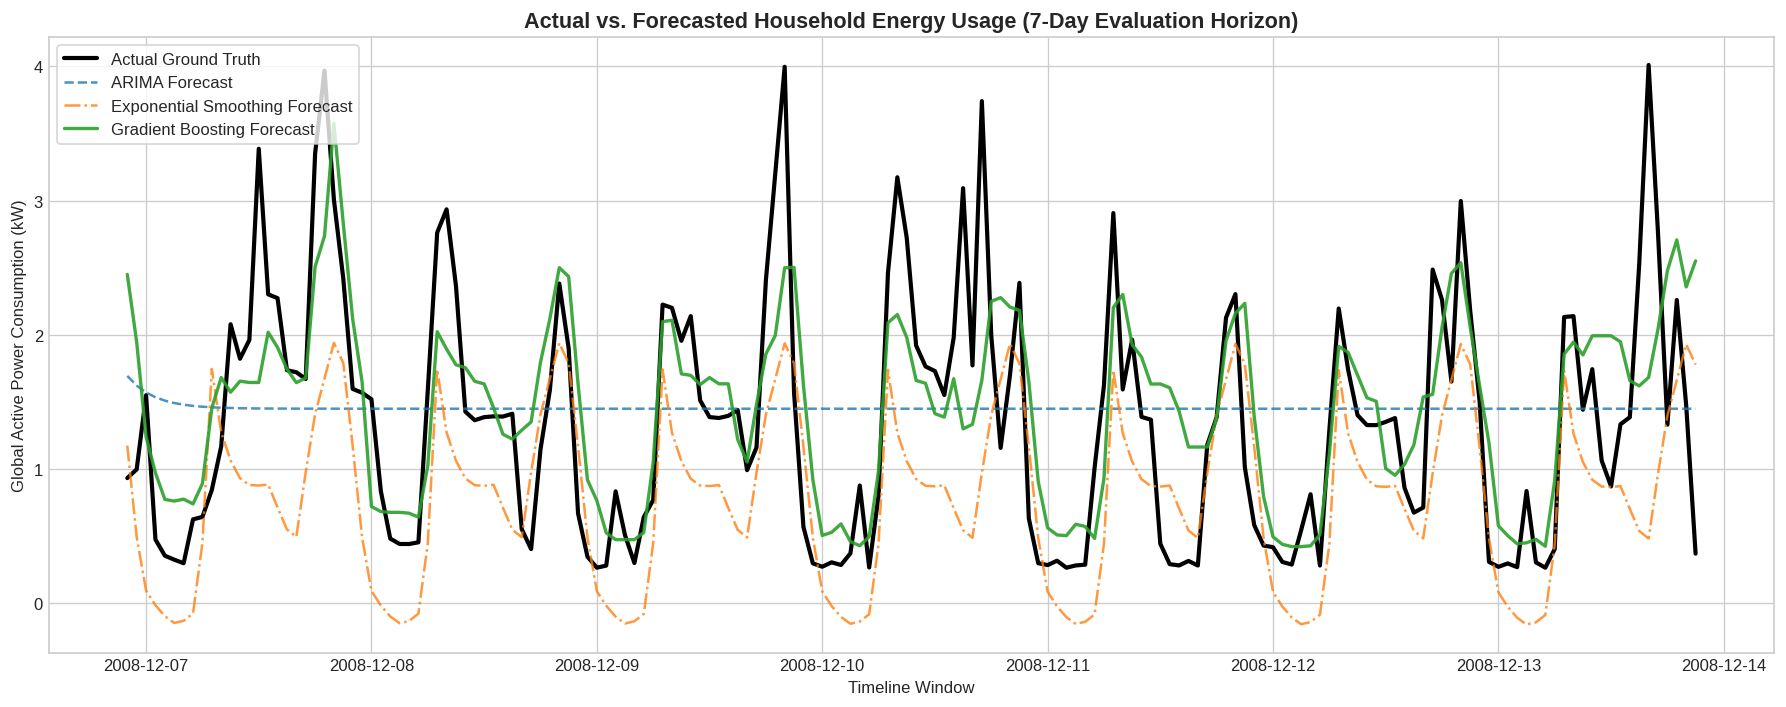

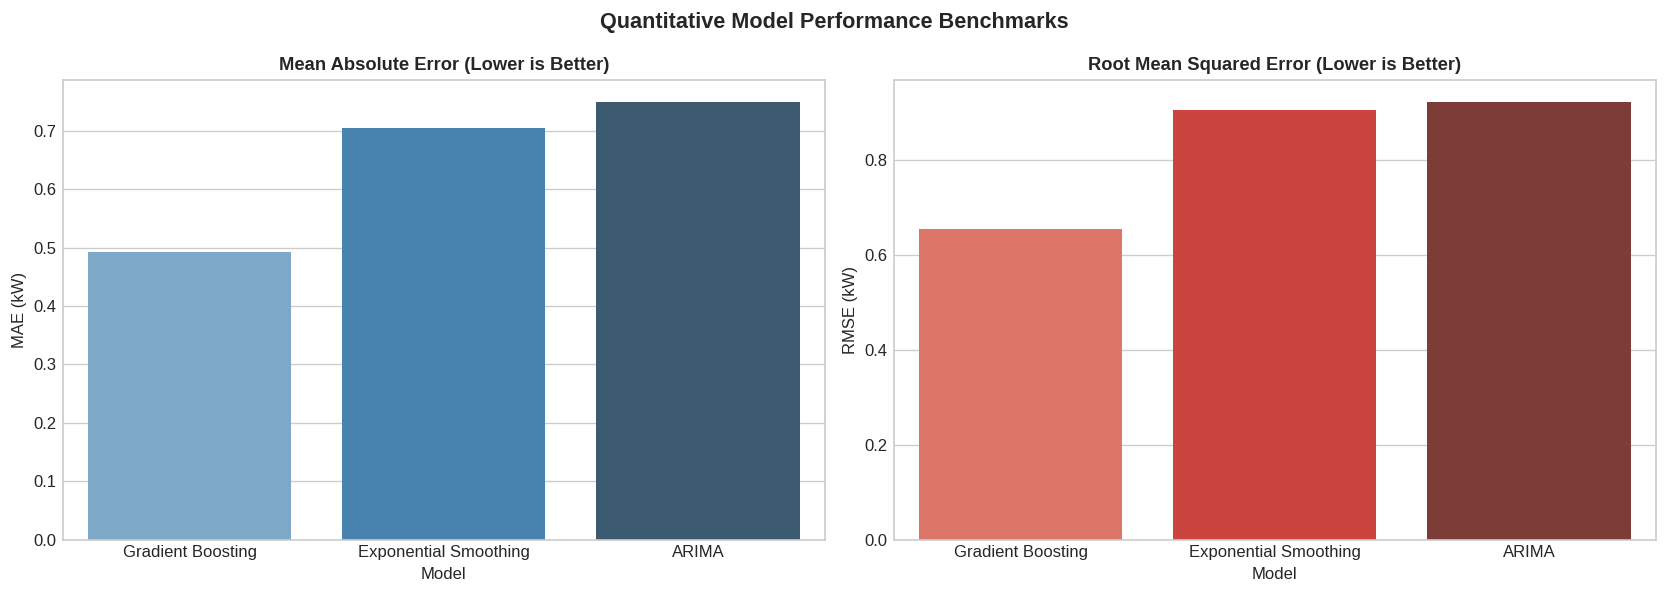

Execution successfully completed. All metrics are calculated and plots are rendered.


In [6]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Setup global presentation formatting
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")


# =====================================================================
# 1. DATA INGESTION & DATA CLEANING
# =====================================================================
def load_and_clean_data(filepath: str) -> pd.DataFrame:
    """Loads raw household power consumption data, builds index, and resamples to hourly grain."""
    print("Initializing Production Data Ingestion Pipeline...")

    df = pd.read_csv(filepath, low_memory=False)

    # Standardize timestamps into a unified index
    df["Datetime"] = df["Date"] + " " + df["Time"]
    df["Datetime"] = pd.to_datetime(df["Datetime"], format="%d/%m/%Y %H:%M:%S", errors="coerce")
    df = df.dropna(subset=["Datetime"])
    df.set_index("Datetime", inplace=True)

    # Convert targets to numbers and handle missing rows via forward-fill
    df["Global_active_power"] = pd.to_numeric(df["Global_active_power"], errors="coerce")
    df["Global_active_power"] = df["Global_active_power"].ffill().bfill()

    # Resample to hourly data to smooth out high-frequency minutely noise
    print("Resampling series to Hourly grain...")
    hourly_df = df[["Global_active_power"]].resample("H").mean()
    hourly_df = hourly_df.ffill().bfill()

    return hourly_df


# =====================================================================
# 2. COMPLETE EXPLORATORY DATA ANALYSIS (EDA) ENGINE
# =====================================================================
def run_exploratory_analysis(df: pd.DataFrame):
    """Generates structural diagnostics mapping consumption profiles and autocorrelations."""
    print("Executing Deep Exploratory Data Analysis and Diagnostic Rendering...")

    df = df.copy()
    df["hour"] = df.index.hour
    df["dayofweek"] = df.index.dayofweek

    # Plot Set 1: Seasonality profiles across hour and day vectors
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=120)
    sns.boxplot(x="hour", y="Global_active_power", data=df, ax=axes[0], palette="Blues")
    axes[0].set_title("Hourly Consumption Profile (Daily Seasonality)", fontsize=11, fontweight="bold")
    axes[0].set_xlabel("Hour of Day")
    axes[0].set_ylabel("Active Power (kW)")

    sns.boxplot(x="dayofweek", y="Global_active_power", data=df, ax=axes[1], palette="Purples")
    axes[1].set_title("Weekly Consumption Profile (0=Mon, 6=Sun)", fontsize=11, fontweight="bold")
    axes[1].set_xlabel("Day of Week")
    axes[1].set_ylabel("Active Power (kW)")
    plt.tight_layout()
    plt.show()  # Renders the seasonality plots directly in the output console/notebook

    # Plot Set 2: Volatility distributions and historical lag correlations
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=120)
    sns.histplot(df["Global_active_power"], kde=True, ax=axes[0], color="teal", bins=50)
    axes[0].set_title("Target Frequency Distribution", fontsize=11, fontweight="bold")
    axes[0].set_xlabel("Global Active Power (kW)")

    plot_acf(df["Global_active_power"].iloc[-720:], lags=48, ax=axes[1], color="darkred")
    axes[1].set_title("Autocorrelation (ACF) over 48-Hour Lags", fontsize=11, fontweight="bold")
    axes[1].set_xlabel("Lags (Hours)")
    plt.tight_layout()
    plt.show()  # Renders the distribution and autocorrelation plots directly in the output


# =====================================================================
# 3. ADVANCED FEATURE ENGINEERING
# =====================================================================
def engineer_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """Creates calendar indicators, cyclical vectors, and temporal lag shifts."""
    df = df.copy()

    df["hour"] = df.index.hour
    df["dayofweek"] = df.index.dayofweek
    df["month"] = df.index.month
    df["dayofyear"] = df.index.dayofyear
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

    # Lag windows to establish long-term and short-term historical context
    df["lag_24h"] = df["Global_active_power"].shift(24)
    df["lag_168h"] = df["Global_active_power"].shift(168)

    # Rolling statistics over a full 24-hour period
    df["rolling_mean_24h"] = df["Global_active_power"].shift(1).rolling(window=24).mean()

    df.dropna(inplace=True)
    return df


# =====================================================================
# 4. MODEL EXECUTION & VALIDATION PIPELINE
# =====================================================================
def main():
    csv_path = "household_power_consumption.csv"

    # Ingestion and EDA step
    base_df = load_and_clean_data(csv_path)
    run_exploratory_analysis(base_df)

    # Feature processing step
    featured_df = engineer_time_features(base_df)

    # Out-of-time chronological train/test split (hold out final 7 days)
    forecast_horizon = 168
    train_data = featured_df.iloc[:-forecast_horizon]
    test_data = featured_df.iloc[-forecast_horizon:]

    # Segment the last 30 days of training data to speed up optimization for linear models
    train_ts = train_data["Global_active_power"].iloc[-720:]
    test_ts = test_data["Global_active_power"]

    results_bench = pd.DataFrame(index=test_data.index)
    results_bench["Actual"] = test_ts
    metrics_summary = {}

    # --- MODEL 1: ARIMA ---
    print("\nTraining Model 1: Classical ARIMA Sequence Model...")
    arima_model = ARIMA(train_ts, order=(1, 1, 1)).fit()
    results_bench["ARIMA"] = arima_model.forecast(steps=forecast_horizon).values

    # --- MODEL 2: Exponential Smoothing (Prophet Framework Alternative) ---
    print("Training Model 2: Holt-Winters Exponential Smoothing...")
    es_model = ExponentialSmoothing(train_ts, seasonal_periods=24, trend="add", seasonal="add").fit()
    results_bench["Exponential Smoothing"] = es_model.forecast(steps=forecast_horizon).values

    # --- MODEL 3: Gradient Boosting (XGBoost Framework Alternative) ---
    print("Training Model 3: Gradient Boosting Ensemble...")
    feature_cols = ["hour", "dayofweek", "month", "dayofyear", "is_weekend", "lag_24h", "lag_168h", "rolling_mean_24h"]
    X_train, y_train = train_data[feature_cols], train_data["Global_active_power"]
    X_test, y_test = test_data[feature_cols], test_data["Global_active_power"]

    gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)
    gbr.fit(X_train, y_train)
    results_bench["Gradient Boosting"] = gbr.predict(X_test)

    # Quantitative Evaluation Engine
    def calculate_metrics(y_true, y_pred, name):
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        print(f"  {name} Results -> MAE: {mae:.4f} kW | RMSE: {rmse:.4f} kW")
        return {"MAE": mae, "RMSE": rmse}

    print("\nEvaluating Model Standings Against Test Ground Truth:")
    metrics_summary["ARIMA"] = calculate_metrics(results_bench["Actual"], results_bench["ARIMA"], "ARIMA")
    metrics_summary["Exponential Smoothing"] = calculate_metrics(results_bench["Actual"], results_bench["Exponential Smoothing"], "Exp Smoothing")
    metrics_summary["Gradient Boosting"] = calculate_metrics(results_bench["Actual"], results_bench["Gradient Boosting"], "Gradient Boosting")

    # =====================================================================
    # 5. HIGH-LEVEL FORECAST VISUALIZATION RENDERERS
    # =====================================================================
    print("\nGenerating Diagnostic Curves and Performance Dashboards...")

    # Chart 3: Main Forecast vs Ground Truth Curves
    fig, ax = plt.subplots(figsize=(15, 6), dpi=120)
    ax.plot(results_bench.index, results_bench["Actual"], label="Actual Ground Truth", color="black", linewidth=2.5)
    ax.plot(results_bench.index, results_bench["ARIMA"], label="ARIMA Forecast", linestyle="--", alpha=0.8)
    ax.plot(results_bench.index, results_bench["Exponential Smoothing"], label="Exponential Smoothing Forecast", linestyle="-.", alpha=0.8)
    ax.plot(results_bench.index, results_bench["Gradient Boosting"], label="Gradient Boosting Forecast", linewidth=2, alpha=0.9)
    ax.set_title("Actual vs. Forecasted Household Energy Usage (7-Day Evaluation Horizon)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Timeline Window")
    ax.set_ylabel("Global Active Power Consumption (kW)")
    ax.legend(loc="upper left", frameon=True)
    plt.tight_layout()
    plt.show()  # Displays the main line forecast comparison plot inline

    # Chart 4: Model Standings Metrics Bar Plot (Sorted Order)
    metrics_df = pd.DataFrame(metrics_summary).T.reset_index().rename(columns={"index": "Model"})
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

    # Sort bar metrics from lowest error to highest error
    df_mae = metrics_df.sort_values(by="MAE")
    sns.barplot(x="Model", y="MAE", data=df_mae, ax=axes[0], palette="Blues_d")
    axes[0].set_title("Mean Absolute Error (Lower is Better)", fontsize=11, fontweight="bold")
    axes[0].set_ylabel("MAE (kW)")

    df_rmse = metrics_df.sort_values(by="RMSE")
    sns.barplot(x="Model", y="RMSE", data=df_rmse, ax=axes[1], palette="Reds_d")
    axes[1].set_title("Root Mean Squared Error (Lower is Better)", fontsize=11, fontweight="bold")
    axes[1].set_ylabel("RMSE (kW)")

    plt.suptitle("Quantitative Model Performance Benchmarks", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()  # Displays the model metric comparison bars inline

    # Export processed historical predictions to a local file
    results_bench.to_csv("transformed_hourly_power_consumption.csv")
    print("Execution successfully completed. All metrics are calculated and plots are rendered.")


if __name__ == "__main__":
    main()